In [4]:
import pandas as pd

# Load Nabil Bank data
df = pd.read_csv("NABIL.csv")

# Check that the file loaded and see its column names
print(df.columns.tolist())
display(df.head(10))


['published_date', 'open', 'high', 'low', 'close', 'per_change', 'traded_quantity', 'traded_amount', 'status']


,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status
0,2011-05-15,1091.0,1155.0,1112.0,1155.0,NaN,38.0,43057.0,0
1,2011-05-16,1155.0,1193.0,1160.0,1193.0,3.29,156.0,183026.0,0
2,2011-05-18,1193.0,1172.0,1150.0,1172.0,-1.76,939.0,1087972.0,0
3,2011-05-19,1172.0,1194.0,1155.0,1194.0,1.88,490.0,573992.0,0
4,2011-05-22,1194.0,1193.0,1178.0,1178.0,-1.34,115.0,135930.0,0
5,2011-05-23,1178.0,1189.0,1165.0,1170.0,-0.68,239.0,279927.0,0
6,2011-05-24,1170.0,1160.0,1150.0,1150.0,-1.71,282.0,325456.0,0
7,2011-05-25,1150.0,1159.0,1100.0,1150.0,0.00,597.0,664216.0,0
8,2011-05-26,1150.0,1149.0,1127.0,1149.0,-0.09,127.0,143553.0,0
9,2011-05-30,1149.0,1151.0,1140.0,1150.0,0.09,320.0,366010.0,0


Rows: 3514
Date range: 2011-05-15 00:00:00 to 2026-09-23 00:00:00


,published_date,close
0,2011-05-15,1155.0
1,2011-05-16,1193.0
2,2011-05-18,1172.0
3,2011-05-19,1194.0
4,2011-05-22,1178.0


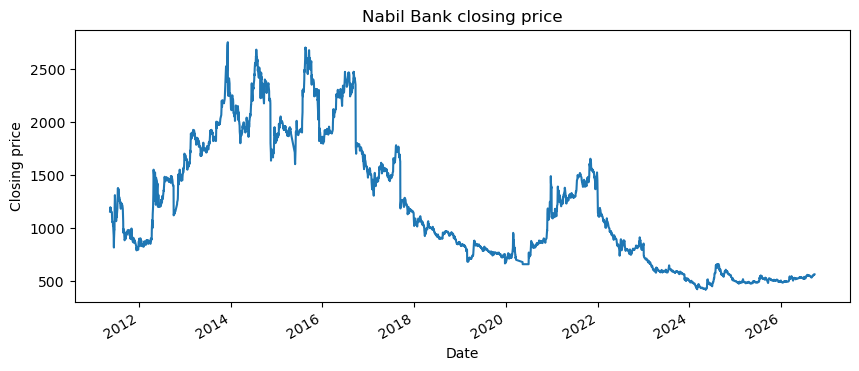

In [5]:
import matplotlib.pyplot as plt

df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
df["close"] = pd.to_numeric(df["close"], errors="coerce")

nabil = df[["published_date", "close"]].dropna()
nabil = nabil.sort_values("published_date")

print("Rows:", len(nabil))
print("Date range:", nabil["published_date"].min(), "to", nabil["published_date"].max())
display(nabil.head())

nabil.plot(x="published_date", y="close", figsize=(10, 4), legend=False)
plt.title("Nabil Bank closing price")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.show()

In [6]:
nabil = nabil.copy()
nabil["daily_return"] = nabil["close"].pct_change() * 100

display(nabil.head(10))
print("Average daily return:", round(nabil["daily_return"].mean(), 3), "%")

,published_date,close,daily_return
0,2011-05-15,1155.0,NaN
1,2011-05-16,1193.0,3.290043
2,2011-05-18,1172.0,-1.760268
3,2011-05-19,1194.0,1.877133
4,2011-05-22,1178.0,-1.340034
5,2011-05-23,1170.0,-0.679117
6,2011-05-24,1150.0,-1.709402
7,2011-05-25,1150.0,0.000000
8,2011-05-26,1149.0,-0.086957
9,2011-05-30,1150.0,0.087032


Average daily return: 0.004 %


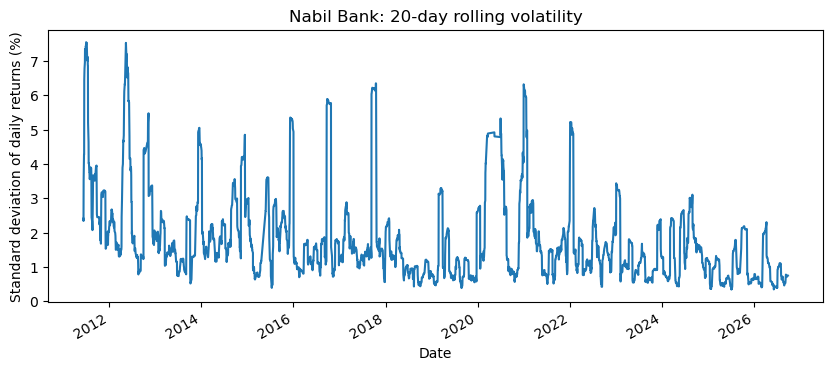

In [7]:
nabil["volatility_20d"] = nabil["daily_return"].rolling(20).std()

nabil.plot(
    x="published_date",
    y="volatility_20d",
    figsize=(10, 4),
    legend=False
)

plt.title("Nabil Bank: 20-day rolling volatility")
plt.xlabel("Date")
plt.ylabel("Standard deviation of daily returns (%)")
plt.show()

In [8]:
from sklearn.metrics import mean_absolute_error

forecast = nabil[["published_date", "close"]].copy()
forecast["actual_next_close"] = forecast["close"].shift(-1)
forecast = forecast.dropna()

test = forecast.iloc[int(len(forecast) * 0.8):].copy()
test["predicted_next_close"] = test["close"]

mae = mean_absolute_error(
    test["actual_next_close"],
    test["predicted_next_close"]
)

print("Days tested:", len(test))
print("Average prediction error (MAE):", round(mae, 2))
display(test.tail(10))

Days tested: 703
Average prediction error (MAE): 4.18


,published_date,close,actual_next_close,predicted_next_close
3503,2026-09-07,552.5,552.0,552.5
3504,2026-09-09,552.0,552.5,552.0
3505,2026-09-10,552.5,552.0,552.5
3506,2026-09-11,552.0,554.0,552.0
3507,2026-09-14,554.0,560.0,554.0
3508,2026-09-15,560.0,560.0,560.0
3509,2026-09-16,560.0,560.0,560.0
3510,2026-09-17,560.0,562.9,560.0
3511,2026-09-18,562.9,565.7,562.9
3512,2026-09-22,565.7,565.0,565.7


In [9]:
forecast["predicted_5day"] = forecast["close"].rolling(5).mean()

test_5day = forecast.iloc[int(len(forecast) * 0.8):].dropna(
    subset=["predicted_5day"]
)

mae_5day = mean_absolute_error(
    test_5day["actual_next_close"],
    test_5day["predicted_5day"]
)

print("Today's-close forecast MAE: 4.18")
print("Five-day-average forecast MAE:", round(mae_5day, 2))

Today's-close forecast MAE: 4.18
Five-day-average forecast MAE: 7.15


In [10]:
returns = nabil["daily_return"].dropna()

print(
    "Correlation between consecutive daily returns:",
    round(returns.autocorr(lag=1), 3)
)

Correlation between consecutive daily returns: 0.122


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model_data = nabil[["close", "daily_return"]].copy()
model_data["next_return"] = model_data["daily_return"].shift(-1)
model_data = model_data.dropna()

split = int(len(model_data) * 0.8)
train = model_data.iloc[:split]
test_model = model_data.iloc[split:].copy()

model = LinearRegression()
model.fit(train[["daily_return"]], train["next_return"])

test_model["predicted_return"] = model.predict(
    test_model[["daily_return"]]
)
test_model["predicted_close"] = test_model["close"] * (
    1 + test_model["predicted_return"] / 100
)
test_model["actual_next_close"] = test_model["close"] * (
    1 + test_model["next_return"] / 100
)

print("Regression MAE:", round(mean_absolute_error(
    test_model["actual_next_close"],
    test_model["predicted_close"]
), 2))
print("Today's-close baseline MAE:", round(mean_absolute_error(
    test_model["actual_next_close"],
    test_model["close"]
), 2))

Regression MAE: 4.16
Today's-close baseline MAE: 4.18


In [12]:
test_model["regression_error"] = (
    test_model["actual_next_close"] - test_model["predicted_close"]
).abs()

test_model["baseline_error"] = (
    test_model["actual_next_close"] - test_model["close"]
).abs()

print(
    "Days regression did better:",
    (test_model["regression_error"] < test_model["baseline_error"]).sum()
)
print("Total test days:", len(test_model))

Days regression did better: 368
Total test days: 703


In [13]:
mid = len(test_model) // 2

for name, part in [
    ("First half", test_model.iloc[:mid]),
    ("Second half", test_model.iloc[mid:])
]:
    print(
        name,
        "| Regression MAE:", round(part["regression_error"].mean(), 2),
        "| Baseline MAE:", round(part["baseline_error"].mean(), 2)
    )

First half | Regression MAE: 5.13 | Baseline MAE: 5.24
Second half | Regression MAE: 3.18 | Baseline MAE: 3.12


In [14]:
mid = len(test_model) // 2

print(
    "First-half return correlation:",
    round(test_model["daily_return"].iloc[:mid].autocorr(lag=1), 3)
)
print(
    "Second-half return correlation:",
    round(test_model["daily_return"].iloc[mid:].autocorr(lag=1), 3)
)

First-half return correlation: 0.13
Second-half return correlation: -0.055
